# Backbone SOH Shape Walkthrough

This notebook uses the external eVTOL dataset only to fit a **general degradation backbone shape**.
Plane 166 is then calibrated onto that backbone in flight-count space.

Short-horizon `5/10/15/...` flight models stay separate. This notebook is only for the long-run shape / trajectory layer.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'ml_workspace').exists() and (candidate / 'data').exists():
            return candidate
    raise RuntimeError('Could not locate repo root from current working directory')

REPO_ROOT = find_repo_root(Path.cwd())
OUTPUT_DIR = REPO_ROOT / 'ml_workspace' / 'soh_forecast' / 'output' / 'backbone_curve_plane_166'

required = [
    OUTPUT_DIR / 'combined_backbone_curve.csv',
    OUTPUT_DIR / 'external_backbone_curve.csv',
    OUTPUT_DIR / 'combined_backbone_points.csv',
    OUTPUT_DIR / 'plane166_backbone_dataset.csv',
    OUTPUT_DIR / 'plane166_backbone_calibration.csv',
    OUTPUT_DIR / 'plane166_backbone_trajectory.csv',
]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        'Missing backbone outputs. Run `.venv/bin/python -m ml_workspace.soh_forecast.fit_backbone_curve` first. '\
        f'Missing: {missing}'
    )

external_curve = pd.read_csv(OUTPUT_DIR / 'external_backbone_curve.csv')
combined_curve = pd.read_csv(OUTPUT_DIR / 'combined_backbone_curve.csv')
combined_points = pd.read_csv(OUTPUT_DIR / 'combined_backbone_points.csv')
plane_df = pd.read_csv(OUTPUT_DIR / 'plane166_backbone_dataset.csv', parse_dates=['event_datetime'])
calibration_df = pd.read_csv(OUTPUT_DIR / 'plane166_backbone_calibration.csv')
trajectory_df = pd.read_csv(OUTPUT_DIR / 'plane166_backbone_trajectory.csv')
summary = json.loads((OUTPUT_DIR / 'run_summary.json').read_text())

summary


{'evtol_point_count': 425,
 'plane_point_count': 376,
 'combined_point_count': 801,
 'calibration_rows': [{'battery_id': 1,
   'start_progress': 0.0,
   'total_life_flights_from_start': 1295.059,
   'end_progress_observed': 0.14439496578920344,
   'fitted_mae': 1.8103506761383708,
   'flights_remaining_to_zero': 1108.059,
   'last_observed_soh_pct': 57.54232883832993},
  {'battery_id': 2,
   'start_progress': 0.0,
   'total_life_flights_from_start': 1632.538,
   'end_progress_observed': 0.11454557259922893,
   'fitted_mae': 1.6285106846159039,
   'flights_remaining_to_zero': 1445.538,
   'last_observed_soh_pct': 60.5588813036762}]}

In [2]:
calibration_df


,battery_id,start_progress,total_life_flights_from_start,end_progress_observed,fitted_mae,flights_remaining_to_zero,last_observed_soh_pct
0,1,0.0,1295.059,0.144395,1.810351,1108.059,57.542329
1,2,0.0,1632.538,0.114546,1.628511,1445.538,60.558881


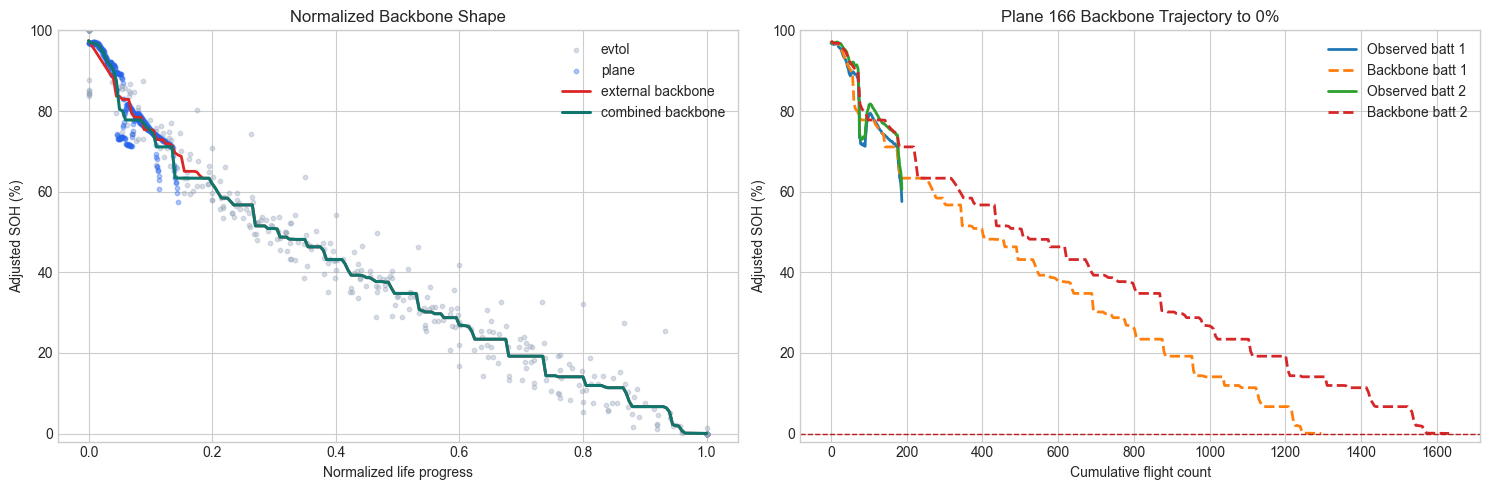

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sample_points = combined_points.sample(min(len(combined_points), 1500), random_state=7)
for source_name, color in [('evtol', '#94a3b8'), ('plane', '#2563eb')]:
    subset = sample_points.loc[sample_points['source'].eq(source_name)]
    axes[0].scatter(subset['progress'], subset['health_pct'], s=10, alpha=0.35, color=color, label=source_name)
axes[0].plot(external_curve['progress'], external_curve['health_pct'], color='#dc2626', linewidth=2.0, label='external backbone')
axes[0].plot(combined_curve['progress'], combined_curve['health_pct'], color='#0f766e', linewidth=2.2, label='combined backbone')
axes[0].set_title('Normalized Backbone Shape')
axes[0].set_xlabel('Normalized life progress')
axes[0].set_ylabel('Adjusted SOH (%)')
axes[0].set_ylim(-2.0, 100.0)
axes[0].legend(loc='best')

for battery_id in sorted(trajectory_df['battery_id'].unique()):
    observed = plane_df.loc[plane_df['battery_id'].eq(battery_id)].sort_values('cumulative_flight_count')
    traj = trajectory_df.loc[trajectory_df['battery_id'].eq(battery_id)].sort_values('cumulative_flight_count')
    axes[1].plot(observed['cumulative_flight_count'], observed['current_soh_pct'], linewidth=2.0, label=f'Observed batt {battery_id}')
    axes[1].plot(traj['cumulative_flight_count'], traj['backbone_soh_pct'], linestyle='--', linewidth=2.0, label=f'Backbone batt {battery_id}')
axes[1].axhline(0.0, color='#b91c1c', linestyle='--', linewidth=1.0)
axes[1].set_title('Plane 166 Backbone Trajectory to 0%')
axes[1].set_xlabel('Cumulative flight count')
axes[1].set_ylabel('Adjusted SOH (%)')
axes[1].set_ylim(-2.0, 100.0)
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()
